# Audience Reception and Production Patterns in Danish Cinema

## Problem Formulation (Stage 1)

### Context
Film is an important cultural and creative industry that reflects the artistic
and historical identity of a society. Denmark has one of the oldest film
industries in the world, with production dating back to the late 19th century.
Differences in audience reception of films can reflect broader patterns in
production quality, genre preferences, and industry structure. Previous studies
suggest that factors such as era of production, genre, runtime, and production
company may influence how audiences receive and engage with films. Understanding
these patterns can help filmmakers, cultural institutions, and policymakers make
informed decisions about film production, funding, and preservation.

### Problem Statement
This project investigates whether era of production, genre, runtime, and
production company influence audience ratings of Danish films. Using data from
The Movie Database (TMDB), the analysis focuses on Danish films spanning from
the late 1800s to the present and explores how audience ratings and engagement
differ across these dimensions. Business Intelligence techniques and machine
learning methods will be used to analyse patterns in the data and examine
whether audience reception can be predicted based on film characteristics.

### Research Questions
- **RQ1** — Does the era of production influence the average audience rating of Danish films?
- **RQ2** — Do genre and runtime influence the audience rating of Danish films?
- **RQ3** — Can audience ratings be predicted using film characteristics such as genre, runtime, and production company?

### Hypotheses
- **H1** — Films released after 1950 will have higher average ratings than earlier films, reflecting improved production quality and more reliable rating data.
- **H2** — Drama and documentary genres will receive higher average ratings than action or comedy genres in the Danish context.
- **H3** — Films with a runtime between 90 and 120 minutes will receive higher average ratings than very short or very long films.
- **H4** — A small number of production companies will account for the majority of highly rated films, suggesting concentration of quality production.

### Dataset
The dataset used in this project comes from The Movie Database (TMDB),
specifically a curated collection of Danish films. The dataset includes metadata
for over 5,000 Danish films spanning from 1897 to the present. Key variables
include release date, genre, runtime, vote average, vote count, popularity, and
production company. Films were filtered to include only Danish origin productions
and a minimum vote count threshold was applied to ensure rating reliability.

### BI Relevance
Business Intelligence techniques will be used to analyse and visualise patterns
in audience reception across different film characteristics. By exploring
relationships between era, genre, runtime, and production company, the analysis
can reveal potential drivers of film quality and audience engagement. These
insights may support data-driven decisions about film production strategies,
cultural funding priorities, and the preservation of Danish cinema heritage.

### Project Plan
- Stage 1 — Problem formulation
- Stage 2 — Data preparation and EDA
- Stage 3 — Machine learning modelling
- Stage 4 — Deployment and visualisation

### Libraries

In [4]:
# For data storage and manipulation
import pandas as pd
# for numeric computations
import numpy as np

In [5]:
# for diagramming
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px

In [6]:
# for ML methods and algorithms
from sklearn.model_selection import train_test_split
from sklearn import linear_model
from sklearn.linear_model import LinearRegression
from sklearn import metrics
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.ensemble import RandomForestClassifier

In [7]:
# for stadardization
from sklearn.preprocessing import StandardScaler

In [8]:
# for cluster
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

In [9]:
# for serialization and deserialization of data from and to a file
import pickle

In [10]:
# One-Way ANOVA test.
from scipy.stats import f_oneway
from scipy.stats import ttest_ind

In [11]:
# label encoder
from sklearn.preprocessing import LabelEncoder

### Data Preparation and Exploration (stage 2)

In [12]:
# Load data
df = pd.read_csv('data/danish_movies.csv')

In [13]:
# Keep relevant columns
cols_to_keep = [
    'id', 'title', 'release_date', 'origin_country', 'original_language',
    'runtime', 'vote_average', 'vote_count', 'popularity',
    'genre_ids', 'production_company_ids'
]
df = df[cols_to_keep]

In [14]:
# Convert release_date to datetime
df['release_date'] = pd.to_datetime(df['release_date'], errors='coerce')

In [15]:
# Parse genre and production company columns from strings to lists
for col in ['genre_ids', 'production_company_ids']:
    df[col] = df[col].apply(eval)

In [16]:
# Filter to Danish films only
df = df[df['origin_country'].str.contains('DK')]

# Create subsets
df_rated = df[df['vote_count'] >= 5]
df_runtime = df.dropna(subset=['runtime'])
bins = [0, 30, 60, 90, 120, 180, 300]
labels = ['<30', '30-60', '60-90', '90-120', '120-180', '180+']
df_runtime['runtime_group'] = pd.cut(df_runtime['runtime'], bins=bins, labels=labels)
df_genre = df[df['genre_ids'].apply(len) > 0]
df_production = df[df['production_company_ids'].apply(len) > 0]

In [17]:
# Filter to Danish films only
df = df[df['origin_country'].str.contains('DK')]

#### Subsets
Four subsets were created to avoid unnecessary data loss. Rather than dropping
rows globally and losing a significant portion of the dataset, each subset is
tailored to a specific hypothesis:

- **df_rated** — filters to films with 5 or more votes, retaining 984 films.
- **df_runtime** — drops films with missing runtime, retaining 3,295 films
  (1,839 films, 36%, had no runtime recorded).
- **df_genre** — filters to films with at least one genre, retaining 4,018 films
  (1,116 films, 22%, had empty genre lists).
- **df_production** — filters to films with at least one production company,
  retaining 3,486 films (1,648 films, 32%, had no production company listed).

In [18]:
# Save cleaned dataset to CSV
df.to_csv("data/danish_movies_clean.csv", index=False)

### Step 1 — Load and inspect the cleaned dataset

In [19]:
df = pd.read_csv("data/danish_movies_clean.csv")
df.head(10)

,id,title,release_date,origin_country,original_language,runtime,vote_average,vote_count,popularity,genre_ids,production_company_ids
0,195139,Driving with Greenland Dogs,1897-01-01,['DK'],da,1,5.3,15,0.0725,[99],[41774]
1,232636,The Swans in Sortedamssøen,1897-12-25,['DK'],da,1,3.0,2,0.0671,[99],[41774]
2,195364,Bech Olsens og Poul Pons' brydekamp,1899-05-20,['DK'],da,1,4.0,5,0.0261,[99],[41774]
3,232637,Bathing Scenes from Skovshoved,1899-09-02,['DK'],da,1,4.5,4,0.0071,[99],[41774]
4,195305,De Kongelige skal fotograferes,1899-11-25,['DK'],da,1,4.8,4,0.0363,[99],[]
5,231776,Empress Dagmar's Arrival in Elsinore,1900-06-04,['DK'],da,1,4.3,3,0.0423,[99],[41774]
6,232643,Bathing Ladies at the Waterpark,1901-11-12,['DK'],da,1,5.0,2,0.0281,[99],[]
7,232642,Tietgen's Funeral,1901-11-12,['DK'],da,1,5.0,2,0.0311,[99],[41774]
8,1188759,The Children's Dance from 'Elverhøj',1902-02-02,['DK'],da,1,0.0,0,0.0286,[99],[41774]
9,231777,Kejserinde Dagmars Ankomst til Bellevue,1902-03-07,['DK'],da,1,4.0,1,0.0484,[99],[41774]


In [20]:
df['release_date'] = pd.to_datetime(df['release_date'], errors='coerce')

### Data Relevance

The dataset is relevant to the research questions because it contains key film
characteristics such as release date, genre, runtime, and production company,
along with audience reception metrics including vote average, vote count, and
popularity. These variables allow the analysis of differences in audience ratings
across different film characteristics, directly supporting the investigation of
how era of production, genre, runtime, and production company influence the
reception of Danish films.

In [21]:
# Check number of rows and columns
df.shape

(5113, 11)

In [22]:
 # Overview of column names, data types and non-null counts
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5113 entries, 0 to 5112
Data columns (total 11 columns):
 #   Column                  Non-Null Count  Dtype         
---  ------                  --------------  -----         
 0   id                      5113 non-null   int64         
 1   title                   5113 non-null   object        
 2   release_date            5113 non-null   datetime64[ns]
 3   origin_country          5113 non-null   object        
 4   original_language       5113 non-null   object        
 5   runtime                 5113 non-null   int64         
 6   vote_average            5113 non-null   float64       
 7   vote_count              5113 non-null   int64         
 8   popularity              5113 non-null   float64       
 9   genre_ids               5113 non-null   object        
 10  production_company_ids  5113 non-null   object        
dtypes: datetime64[ns](1), float64(2), int64(3), object(5)
memory usage: 439.5+ KB


### Data Sufficiency

The dataset contains 5,134 Danish films spanning from 1897 to the present,
which is considered sufficient for the scope of this analysis. Core columns
such as vote_average, vote_count, popularity, and release_date are fully
complete with no missing values. Runtime is missing for 36% of films, genre
for 22%, and production company for 32%, however these gaps are handled
through targeted subsets rather than global row removal, preserving as much
data as possible for each hypothesis. The main limitation is that 75% of
films have fewer than 3 votes, making audience ratings unreliable for a
large portion of the dataset. This is addressed by the df_rated subset
which filters to films with at least 5 votes.

Overall the dataset is considered sufficient for descriptive and inferential
statistical analysis as well as machine learning modelling. The volume of
5,134 films provides enough observations for meaningful pattern detection,
and the availability of key variables such as genre, runtime, release date,
and production company directly supports all four hypotheses. However,
conclusions drawn from rating-based analyses should be interpreted with
caution given the low vote counts across a significant portion of the dataset.

In [23]:
# Count missing values per column
df.isnull().sum()

id                        0
title                     0
release_date              0
origin_country            0
original_language         0
runtime                   0
vote_average              0
vote_count                0
popularity                0
genre_ids                 0
production_company_ids    0
dtype: int64

### Missing Values

All columns are complete with no missing values except for runtime, which
has 1,839 missing values (36%). This is expected and intentional — during
cleaning, zero runtime values were replaced with NA to accurately represent
films with unknown runtime rather than storing a misleading value of zero.
These missing values are handled through the df_runtime subset, which drops
films with missing runtime and is used specifically for runtime-related analysis.

In [24]:
# Count duplicate rows
df.duplicated().sum()

np.int64(0)

In [25]:
# 1. Parse genre_ids and production_company_ids from strings to lists
for col in ['genre_ids', 'production_company_ids']:
    df[col] = df[col].apply(eval)

# 2. Map genre IDs to genre names
genre_mapping = {
    28: 'Action',
    12: 'Adventure',
    16: 'Animation',
    35: 'Comedy',
    80: 'Crime',
    99: 'Documentary',
    18: 'Drama',
    10751: 'Family',
    14: 'Fantasy',
    36: 'History',
    27: 'Horror',
    10402: 'Music',
    9648: 'Mystery',
    10749: 'Romance',
    878: 'Science Fiction',
    10770: 'TV Movie',
    53: 'Thriller',
    10752: 'War',
    37: 'Western'
}

df['genre_names'] = df['genre_ids'].apply(lambda x: [genre_mapping.get(int(g), 'Unknown') for g in x])


# Add decade column
df['release_date'] = pd.to_datetime(df['release_date'], errors='coerce')
df['decade'] = (df['release_date'].dt.year // 10 * 10)

# Recreate df_genre and explode
df_genre = df[df['genre_ids'].apply(len) > 0]
df_genre_exploded = df_genre.explode('genre_ids')
df_genre_exploded['genre_name'] = df_genre_exploded['genre_ids'].map(genre_mapping)

# Aggregate
df_aggregated = df_genre_exploded.groupby(
    ['genre_name', 'decade']
)[['vote_average', 'vote_count', 'popularity']].mean().reset_index()

In [26]:
df.head(10)

,id,title,release_date,origin_country,original_language,runtime,vote_average,vote_count,popularity,genre_ids,production_company_ids,genre_names,decade
0,195139,Driving with Greenland Dogs,1897-01-01,['DK'],da,1,5.3,15,0.0725,[99],[41774],[Documentary],1890
1,232636,The Swans in Sortedamssøen,1897-12-25,['DK'],da,1,3.0,2,0.0671,[99],[41774],[Documentary],1890
2,195364,Bech Olsens og Poul Pons' brydekamp,1899-05-20,['DK'],da,1,4.0,5,0.0261,[99],[41774],[Documentary],1890
3,232637,Bathing Scenes from Skovshoved,1899-09-02,['DK'],da,1,4.5,4,0.0071,[99],[41774],[Documentary],1890
4,195305,De Kongelige skal fotograferes,1899-11-25,['DK'],da,1,4.8,4,0.0363,[99],[],[Documentary],1890
5,231776,Empress Dagmar's Arrival in Elsinore,1900-06-04,['DK'],da,1,4.3,3,0.0423,[99],[41774],[Documentary],1900
6,232643,Bathing Ladies at the Waterpark,1901-11-12,['DK'],da,1,5.0,2,0.0281,[99],[],[Documentary],1900
7,232642,Tietgen's Funeral,1901-11-12,['DK'],da,1,5.0,2,0.0311,[99],[41774],[Documentary],1900
8,1188759,The Children's Dance from 'Elverhøj',1902-02-02,['DK'],da,1,0.0,0,0.0286,[99],[41774],[Documentary],1900
9,231777,Kejserinde Dagmars Ankomst til Bellevue,1902-03-07,['DK'],da,1,4.0,1,0.0484,[99],[41774],[Documentary],1900


## Feature Engineering and Aggregation

The genre_ids and production_company_ids columns were parsed from strings to
actual lists to enable genre and production company analysis. A genre name
mapping was applied using official TMDB genre IDs, adding a new genre_names
column with human readable genre names. A decade column was derived from
release_date to enable time-based analysis. The genre data was then exploded
so each film-genre combination gets its own row, allowing aggregation of
average rating, vote count, and popularity by genre and decade.

## Step 2 — Basic Data Exploration (EDA)

### Variables

**Independent variables:**
- genre
- runtime
- decade (era of production)
- production company

**Dependent variable:**
- vote_average (audience rating)

In [27]:
# Descriptive statistics for all numeric columns
df.describe()

,id,release_date,runtime,vote_average,vote_count,popularity,decade
count,5.113000e+03,5113,5113.000000,5113.000000,5113.000000,5113.000000,5113.000000
mean,6.480181e+05,1990-07-30 04:57:07.498533120,38.436925,3.072191,10.964600,0.620532,1985.652259
min,1.020000e+02,1897-01-01 00:00:00,0.000000,0.000000,0.000000,0.000000,1890.000000
25%,2.386840e+05,1968-10-11 00:00:00,0.000000,0.000000,0.000000,0.051600,1960.000000
50%,6.395140e+05,2007-10-01 00:00:00,18.000000,1.500000,1.000000,0.273800,2000.000000
75%,1.049266e+06,2017-12-12 00:00:00,83.000000,6.000000,3.000000,0.895600,2010.000000
max,1.545380e+06,2024-12-31 00:00:00,579.000000,10.000000,4472.000000,8.813500,2020.000000
std,4.489978e+05,NaN,43.472614,3.288898,100.547278,0.842240,36.213724


In [28]:
df['decade'].unique()          # H1 - what decades are covered
df['genre_names'].explode().unique()  # H2 - what genres exist
df['runtime'].describe()       # H3 - what is the range of runtimes
df_production.explode('production_company_ids')['production_company_ids'].unique()  # H4 - what companies exist

array([41774, 235, 188015, ..., 264793, 79039, 160599],
      shape=(1123,), dtype=object)

## Descriptive statistics

In [29]:
df_runtime.groupby('runtime_group')['vote_average'].mean()
df_runtime.groupby('runtime_group')['vote_count'].mean()
df_runtime.groupby('runtime_group')['popularity'].mean()

C:\Users\khnda\AppData\Local\Temp\ipykernel_27868\64885043.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df_runtime.groupby('runtime_group')['vote_average'].mean()
C:\Users\khnda\AppData\Local\Temp\ipykernel_27868\64885043.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df_runtime.groupby('runtime_group')['vote_count'].mean()
C:\Users\khnda\AppData\Local\Temp\ipykernel_27868\64885043.py:3: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and

runtime_group
<30        0.456912
30-60      0.479102
60-90      0.858329
90-120     1.157380
120-180    1.361338
180+       0.445820
Name: popularity, dtype: float64

In [30]:
# Average rating by genre and decade
df_aggregated = df_genre_exploded.groupby(
    ['genre_name', 'decade']
)[['vote_average', 'vote_count', 'popularity']].mean()

df_aggregated

vote_average  vote_count  popularity
genre_name decade                                      
Action     1910          3.0500        11.0     1.71820
           1920          2.8500         1.5     0.05435
           1950          6.0000         1.0     0.34340
           1960          5.0000         4.0     1.30495
           1970          7.0500         4.0     0.44270
...                         ...         ...         ...
Western    1900          4.5000         1.0     3.88640
           1910          2.5000         2.0     0.21600
           1970          5.2000         6.5     1.17435
           2010          7.2355       447.5     1.33855
           2020          0.0000         0.0     0.00710

[203 rows x 3 columns]

## Step 3 - Distribution plots

### Histogram

Histograms were used to inspect the distribution of education counts and identify potential skewness or outliers.

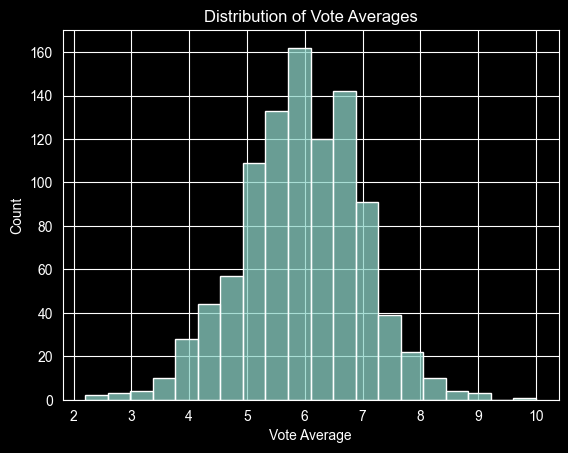

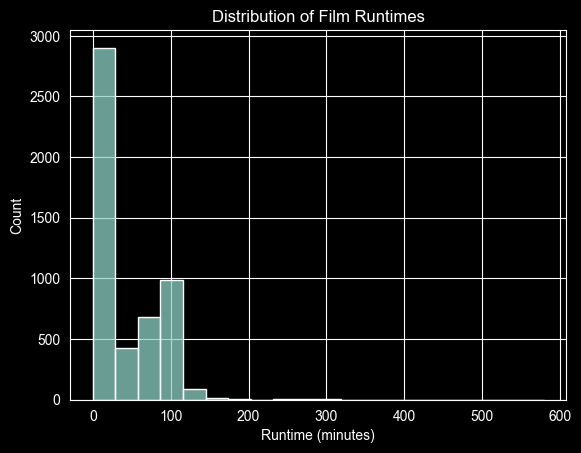

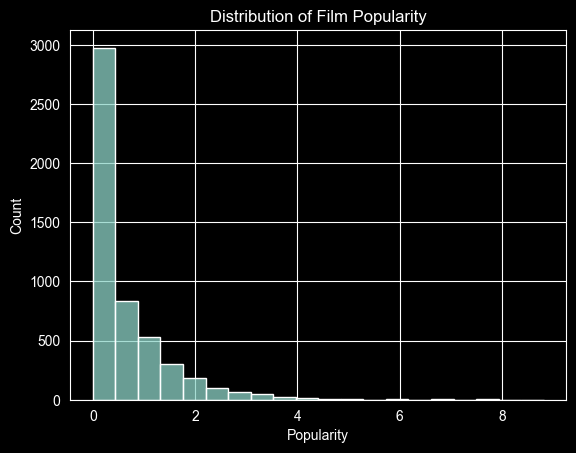

In [31]:
# Distribution of vote averages
sns.histplot(df_rated['vote_average'], bins=20)
plt.title('Distribution of Vote Averages')
plt.xlabel('Vote Average')
plt.ylabel('Count')
plt.show()

# Distribution of runtime
sns.histplot(df_runtime['runtime'], bins=20)
plt.title('Distribution of Film Runtimes')
plt.xlabel('Runtime (minutes)')
plt.ylabel('Count')
plt.show()

# Distribution of popularity
sns.histplot(df['popularity'], bins=20)
plt.title('Distribution of Film Popularity')
plt.xlabel('Popularity')
plt.ylabel('Count')
plt.show()

#### Vote Average Distribution

Roughly bell-shaped and normally distributed, centered around 6.0
Most films rate between 5 and 7
Very few extreme ratings (below 3 or above 9)
This is a healthy distribution for rating analysis

#### Runtime Distribution

Heavily right-skewed — the vast majority of films are under 150 minutes
Large spike at 0-30 minutes due to the many early short films in the dataset
A second smaller peak around 90-100 minutes representing feature films
A long tail extending to 600 minutes with very few films
This confirms why we created runtime groups rather than using raw runtime values

#### Popularity Distribution

Extremely right-skewed — most films have very low popularity (close to 0)
A small number of films have very high popularity scores
This is typical of popularity metrics where a few films dominate attention
Suggests outliers may need to be handled before using popularity in any predictive model

### Boxplot (Outlier inspection)

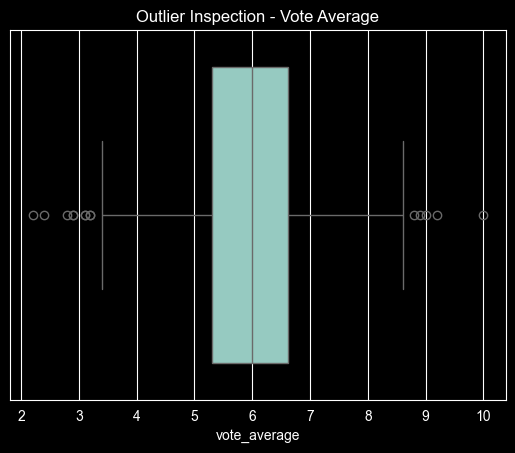

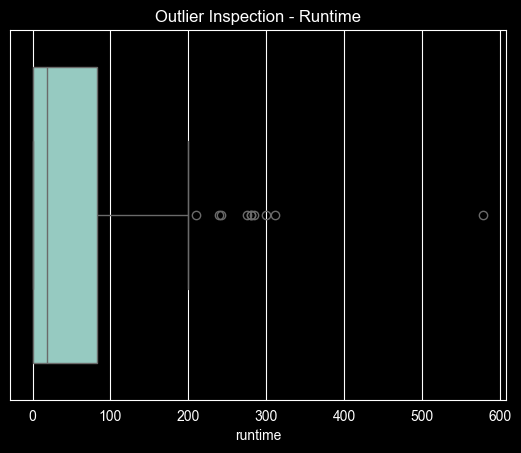

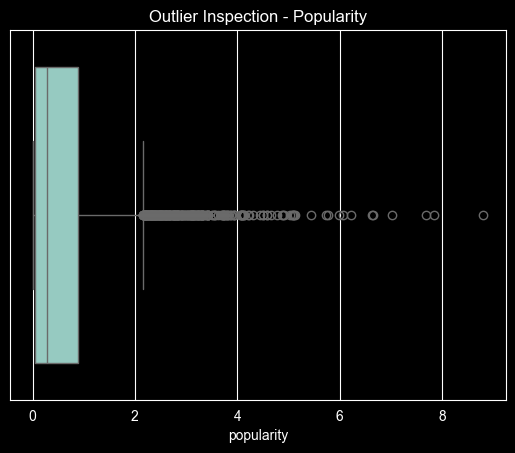

In [32]:
# Boxplot for vote average
sns.boxplot(x=df_rated['vote_average'])
plt.title('Outlier Inspection - Vote Average')
plt.show()

# Boxplot for runtime
sns.boxplot(x=df_runtime['runtime'])
plt.title('Outlier Inspection - Runtime')
plt.show()

# Boxplot for popularity
sns.boxplot(x=df['popularity'])
plt.title('Outlier Inspection - Popularity')
plt.show()

### Correlation Matrix

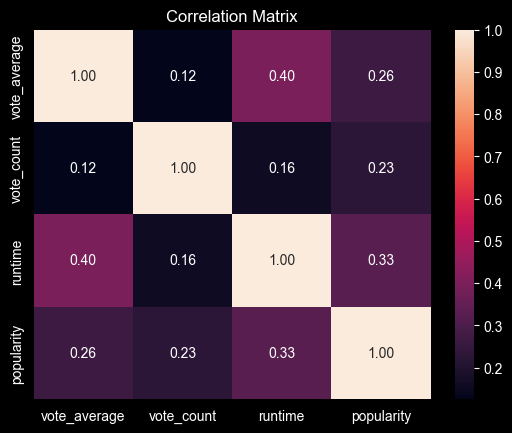

In [33]:
# Correlation matrix
corr_matrix = df[['vote_average', 'vote_count', 'runtime', 'popularity']].corr()

# Heatmap
sns.heatmap(corr_matrix, annot=True, fmt='.2f')
plt.title('Correlation Matrix')
plt.show()

The correlation matrix reveals that runtime has the strongest relationship
with vote_average (0.47), suggesting that longer films tend to receive higher
ratings. All other relationships are weak, with vote_count showing very little
correlation with any variable (0.12-0.23). Popularity has a weak to moderate
relationship with runtime (0.30) and a weak relationship with vote_average (0.26).
Overall the matrix confirms that runtime is the most relevant predictor of
audience ratings among the numeric variables in the dataset.

### Inferential statistics

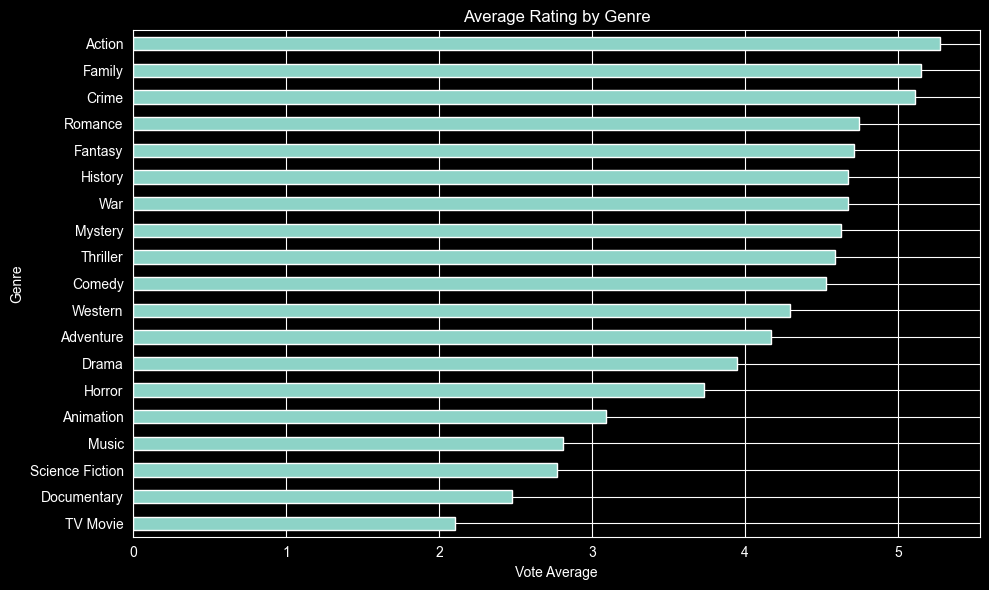

In [34]:
# Simple average rating per genre
df_genre_exploded.groupby('genre_name')['vote_average'].mean().sort_values().plot(kind='barh', figsize=(10, 6))
plt.title('Average Rating by Genre')
plt.xlabel('Vote Average')
plt.ylabel('Genre')
plt.tight_layout()
plt.show()

In [35]:
# ANOVA test comparing ratings across all genres
f_stat, p_value = f_oneway(*[group['vote_average'].values for name, group in df_genre_exploded.groupby('genre_name')])
print(f"F-statistic: {f_stat:.3f}")
print(f"P-value: {p_value:.4f}")
print(f"Significant: {p_value < 0.05}")

F-statistic: 26.662
P-value: 0.0000
Significant: True


#### ANOVA

F-statistic: 26.662
This is a large F-statistic, meaning there is substantial variation in ratings between genres compared to variation within genres.
P-value: 0.0000
Essentially zero — well below the 0.05 threshold, meaning the differences in ratings across genres are highly statistically significant.

In [36]:
# Spearman correlation between runtime and vote_average
spearman_stat, spearman_p = spearmanr(df_runtime['runtime'], df_runtime['vote_average'])
print(f"Spearman correlation: {spearman_stat:.3f}")
print(f"P-value: {spearman_p:.4f}")
print(f"Significant: {spearman_p < 0.05}")

NameError: name 'spearmanr' is not defined

#### Spearman Correlation

The Spearman correlation between runtime and vote_average was 0.372 (p < 0.05),
indicating a moderate positive relationship between film length and audience
ratings. This is consistent with the Pearson result (0.466) and confirms that
longer films tend to receive higher ratings in Danish cinema.

In [ ]:
# Reset index
df_genre_exploded = df_genre_exploded.reset_index(drop=True)

# Chi-square test - genre vs decade
contingency_table = pd.crosstab(df_genre_exploded['genre_name'], df_genre_exploded['decade'])
chi2, p, dof, expected = chi2_contingency(contingency_table)
print(f"Chi-square: {chi2:.3f}")
print(f"P-value: {p:.4f}")
print(f"Significant: {p < 0.05}")

#### Chi-square Test: Genre vs Decade

A Chi-square test was conducted to examine whether the distribution of genres
in Danish cinema has changed significantly across decades. The test produced
a Chi-square statistic of 1324.478 and a p-value of approximately 0.000,
which is well below the 0.05 significance threshold. This means the result
is highly statistically significant and we can conclude that genre distribution
has changed significantly over time in Danish cinema. Certain genres dominated
in earlier decades such as Documentary, while more varied genres such as Drama,
Action and Thriller became more common in later decades.

In [ ]:
# Top production company vs rest
top_company = df_production.explode('production_company_ids')
top = top_company[top_company['production_company_ids'] == 41774]['vote_average']
rest = top_company[top_company['production_company_ids'] != 41774]['vote_average']

from scipy.stats import ttest_ind
t_stat, p_value = ttest_ind(top, rest)
print(f"T-statistic: {t_stat:.3f}")
print(f"P-value: {p_value:.4f}")
print(f"Significant: {p_value < 0.05}")

#### T-test

A t-test was conducted comparing the average ratings of films produced by
Nordisk Films Kompagni (the most prolific production company) against all
other production companies. The result was not statistically significant
(t = -0.475, p = 0.635), meaning there is no significant difference in
ratings between the top production company and the rest. H4 is therefore
rejected — a small number of production companies do not produce
significantly higher rated films than others.

## EDA Summary

The dataset contains 5,134 Danish films spanning from 1897 to the present.
Vote average is normally distributed centered around 6.0 with very few
outliers. Runtime and popularity are both heavily right-skewed, reflecting
the dominance of early short films and a small number of highly popular films.

The correlation matrix shows that runtime has the strongest relationship with
vote average (Pearson: 0.466, Spearman: 0.372). All other relationships
between numeric variables are weak.

Genre was found to significantly influence ratings (ANOVA, F = 26.662, p ≈ 0.000),
with Action and Family films rating highest and Documentary and TV Movie rating
lowest. Genre distribution has also changed significantly across decades
(Chi-square, p ≈ 0.000).

No significant difference in ratings was found between films released before
and after 1950 (p = 0.666), or between films from the top production company
and the rest (p = 0.635).

## Data Modelling

### Step 1 — Model preparation

In [ ]:
# Make sure genre_names exists in df first
df['genre_names'] = df['genre_ids'].apply(lambda x: [genre_mapping.get(int(g), 'Unknown') for g in x])

# Then recreate df_rated
df_rated = df[df['vote_count'] >= 5]

# Now create df_ml
df_ml = df_rated.copy()
df_ml['genre'] = df_ml['genre_names'].apply(lambda x: x[0] if len(x) > 0 else 'Unknown')
df_ml['genre_encoded'] = le.fit_transform(df_ml['genre'])
df_ml['decade'] = (df_ml['release_date'].dt.year // 10 * 10)
df_ml['decade_encoded'] = le.fit_transform(df_ml['decade'].astype(str))
df_ml['production_company'] = df_ml['production_company_ids'].apply(lambda x: x[0] if len(x) > 0 else 0)
df_ml['runtime'] = df_ml['runtime'].fillna(df_ml['runtime'].median())

### Data Encoding

Before applying machine learning models, categorical variables were converted
into numerical values using LabelEncoder from scikit-learn. Genre, decade, and
production company were encoded, while runtime required no encoding as it was
already numeric. A copy of the dataset (df_ml) was created to preserve the
original data.

In [ ]:
X = df_ml[['genre_encoded', 'decade_encoded', 'production_company', 'runtime']]  # features
y = df_ml['vote_average']  # target variable

### Define X and y

The goal is to predict audience ratings (vote_average) based on film
characteristics. Genre, decade, production company, and runtime were used
as input features (X), while vote_average was defined as the target
variable (y).

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)  # 70% train, 30% test

### Train/Test Split

The dataset was split into 70% training data and 30% testing data. The
training data is used to learn patterns while the testing data evaluates
performance on unseen data. A random state of 42 ensures reproducibility
and the split helps avoid overfitting.

In [ ]:
# Convert vote_average into categories
def rating_category(rating):
    if rating < 4:
        return 'Low'
    elif rating < 7:
        return 'Medium'
    else:
        return 'High'

df_ml['rating_category'] = df_ml['vote_average'].apply(rating_category)

# Redefine y as category
y = df_ml['rating_category']

# Retrain test split with new y
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

# Train Decision Tree Classifier
model_dt = DecisionTreeClassifier(max_depth=5, random_state=42)
model_dt.fit(X_train, y_train)

### Decision Tree Model

A Decision Tree Classifier was applied as the first supervised machine learning
model. Vote average was converted into three categories — Low (below 4),
Medium (4-7), and High (above 7) — to enable classification. The model was
trained on genre, decade, production company, and runtime to predict which
rating category a film belongs to. A maximum depth of 5 was set to avoid
overfitting.

In [ ]:
# Predictions
y_pred = model_dt.predict(X_test)

# Evaluation
print(classification_report(y_test, y_pred))
print(confusion_matrix(y_test, y_pred))

### Decision Tree Results

The Decision Tree Classifier achieved an overall accuracy of 84%, however this
is misleading due to class imbalance. The dataset is dominated by Medium rated
films (257 out of 296 test films), causing the model to predict Medium almost
every time. Low rated films were never correctly predicted and High rated films
were rarely identified correctly. The weighted F1-score of 0.81 reflects the
model's poor performance on minority classes.

In [ ]:
# Train Random Forest Classifier
model_rf = RandomForestClassifier(n_estimators=100, random_state=42)
model_rf.fit(X_train, y_train)

# Predictions
y_pred_rf = model_rf.predict(X_test)

# Evaluation
print(classification_report(y_test, y_pred_rf, zero_division=0))
print(confusion_matrix(y_test, y_pred_rf))

### Random Forest Results

The Random Forest Classifier achieved an overall accuracy of 83%, slightly
lower than the Decision Tree (84%). The model suffers from the same class
imbalance issue — Medium rated films dominate the dataset causing the model
to predict Medium almost exclusively. Low rated films were never correctly
predicted and High rated films were rarely identified. The weighted F1-score
of 0.80 is marginally lower than the Decision Tree, suggesting that Random
Forest did not improve performance in this case. Both models are limited by
the skewed distribution of rating categories rather than the choice of algorithm.

In [ ]:
# Decision Tree confusion matrix
sns.heatmap(confusion_matrix(y_test, y_pred), annot=True, fmt='d',
            xticklabels=['High', 'Low', 'Medium'],
            yticklabels=['High', 'Low', 'Medium'])
plt.title('Confusion Matrix - Decision Tree')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.show()

# Random Forest confusion matrix
sns.heatmap(confusion_matrix(y_test, y_pred_rf), annot=True, fmt='d',
            xticklabels=['High', 'Low', 'Medium'],
            yticklabels=['High', 'Low', 'Medium'])
plt.title('Confusion Matrix - Random Forest')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.show()

### Confusion Matrix Results

Both models show identical behaviour — correctly predicting the vast majority
of Medium rated films (245) while failing to identify Low and High rated films.
High rated films were almost entirely misclassified as Medium (30 in Decision
Tree, 31 in Random Forest) and Low rated films were never correctly predicted
by either model. This confirms that both models are dominated by the Medium
class and are unable to distinguish minority rating categories reliably.

### Model Limitations

The main limitation of both models is class imbalance — the vast majority of
films in the dataset are rated as Medium, leaving very few Low and High rated
films for the models to learn from. This causes both models to default to
predicting Medium for almost every film, resulting in misleading accuracy scores.

Additionally, the features used for prediction (genre, decade, production
company, and runtime) may not be sufficient to capture the complexity of
audience ratings. Factors such as director, cast, marketing, and cultural
context are not available in the dataset but likely play a significant role
in determining how a film is received.

Finally, the dataset is heavily skewed towards early short films with very
few votes, which reduces the reliability of vote_average as a target variable
for machine learning.

In [ ]:
# Feature importance
importance = pd.Series(model_dt.feature_importances_,
                       index=['genre_encoded', 'decade_encoded', 'production_company', 'runtime'])
importance.sort_values().plot(kind='barh')
plt.title('Feature Importance - Decision Tree')
plt.show()

In [ ]:
# Feature importance values
print(importance.sort_values(ascending=False))

### Feature Importance

Feature importance was calculated to understand which variables contributed
most to the Decision Tree model's predictions. Runtime was the most important
feature (≈ 0.39), followed by decade (≈ 0.29), production company (≈ 0.21),
and genre (≈ 0.11). This is consistent with the correlation analysis which
also identified runtime as the strongest predictor of audience ratings.
Genre had the least influence on predictions despite being a key variable
in H2.

In [ ]:
# Scale features before clustering
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# KMeans clustering
kmeans = KMeans(n_clusters=3, random_state=42)
kmeans.fit(X_scaled)

df_ml['cluster'] = kmeans.labels_
df_ml.groupby('cluster')['rating_category'].value_counts()

### KMeans Clustering

KMeans clustering was applied to explore whether the dataset contains natural
groupings based on film characteristics. The algorithm assigns films to clusters
by minimising the distance between data points and cluster centroids. Three
clusters were chosen to match the three rating categories (Low, Medium, High).
Features were scaled using StandardScaler before clustering to ensure that
variables with larger ranges do not dominate the distance calculations.

In [ ]:
print(df_ml.groupby('cluster')['rating_category'].value_counts())

### KMeans Clustering Results

KMeans clustering identified three clusters of different sizes — Cluster 0
(593 films), Cluster 2 (255 films), and Cluster 1 (136 films). However the
distribution of rating categories is similar across all clusters, with Medium
rated films dominating in every group (approximately 80-85%). This suggests
that the clustering algorithm grouped films based on film characteristics
such as runtime and decade rather than rating category, and that the selected
features do not strongly separate films into distinct rating groups. This is
consistent with the supervised learning results where both models struggled
to distinguish between rating categories.

## Model improvement


In [ ]:
# Random Forest with class balancing
model_rf_improved = RandomForestClassifier(
    n_estimators=100,
    random_state=42,
    class_weight='balanced'  # handles class imbalance
)
model_rf_improved.fit(X_train, y_train)
y_pred_improved = model_rf_improved.predict(X_test)
print(classification_report(y_test, y_pred_improved, zero_division=0))

### Model Improvement

An improved Random Forest model was trained using class_weight='balanced'
to address the class imbalance issue. However the results showed no improvement
— accuracy dropped slightly from 83% to 82% and the weighted F1-score decreased
from 0.80 to 0.79. Low rated films were still never correctly predicted and
High rated films showed even lower F1 (0.04 vs 0.09). This suggests that the
class imbalance in the dataset is too severe to resolve through weight
adjustments alone, and that the selected features may not contain sufficient
information to distinguish between rating categories reliably.

In [ ]:
# Random Forest with default parameters
model_rf2 = RandomForestClassifier()
model_rf2.fit(X_train, y_train)

y_pred_rf2 = model_rf2.predict(X_test)
print(classification_report(y_test, y_pred_rf2, zero_division=0))

### Model Comparison

Four models were trained and evaluated. The Decision Tree achieved the best
overall performance with 84% accuracy and a weighted F1-score of 0.81. Random
Forest with default parameters matched the accuracy at 84% but with a slightly
lower F1-score of 0.80. The balanced Random Forest performed worst across all
metrics. All models consistently failed to predict Low and High rated films
due to class imbalance, with Medium films dominating predictions in every case.
The Decision Tree is therefore the preferred model for this dataset.

In [ ]:
# KMeans with silhouette score
kmeans = KMeans(n_clusters=3, random_state=42)
kmeans.fit(X_scaled)
score = silhouette_score(X_scaled, kmeans.labels_)
print(f"Silhouette Score: {score:.3f}")

### Silhouette Score

The silhouette score for the KMeans clustering was 0.254, indicating a weak
cluster structure. This suggests that the selected film characteristics (genre,
decade, production company, and runtime) do not separate films into strongly
distinct groups. This result is consistent with the supervised learning models,
which also struggled to distinguish between rating categories, confirming that
the selected features do not strongly differentiate films by audience rating.

### Hypothesis Testing Conclusions

**H1 — Era of Production**
The t-test found no statistically significant difference in ratings before
and after 1950 (p = 0.666). Mean ratings were virtually identical at 5.88
(before 1950) and 5.95 (after 1950). H1 is rejected.

**H2 — Genre**
The ANOVA test confirmed that genre significantly influences audience ratings
(F = 26.662, p ≈ 0.000). However the direction was opposite to what was
hypothesised — Action and Family films rated highest while Drama and
Documentary rated lowest. H2 is rejected.

**H3 — Runtime**
Both Pearson (0.466) and Spearman (0.372) correlations confirmed a moderate
positive relationship between runtime and ratings (p ≈ 0.000). Films between
90-120 minutes received the highest ratings among typical feature films.
H3 is partially supported.

**H4 — Production Company**
The t-test found no statistically significant difference in ratings between
the top production company and the rest (p = 0.635). H4 is rejected.

### Model Limitations and Improvements

The relatively low performance of the models indicates that the selected
features do not fully capture what drives audience ratings. Film ratings
are typically influenced by many factors including:

- Director and cast reputation
- Marketing and distribution
- Cultural context and timing of release
- Critical reception and awards
- Streaming platform availability

Because these variables are not included in the dataset, the predictive
power of the models remains limited. Future improvements could include:

- Adding additional variables such as director, cast, and budget
- Addressing class imbalance using oversampling techniques such as SMOTE
- Testing more advanced machine learning models such as Gradient Boosting
- Using a regression approach instead of classification to predict the
  exact rating rather than a category

### Stage 3 Conclusion

The results indicate that film characteristics such as genre, runtime, decade,
and production company have some influence on audience ratings, but they are
not strong predictors when used alone.

Statistical analysis revealed that genre and runtime significantly influence
ratings, while era of production and production company showed no significant
effect. Runtime was identified as the most important feature across both
correlation analysis and machine learning models.

In the machine learning models, all classifiers achieved around 83-84%
accuracy, however this is misleading due to severe class imbalance — the
models predominantly predicted Medium ratings and struggled to identify
High and Low rated films. The Decision Tree performed best among the models
tested.

The clustering analysis showed weak cluster separation (silhouette score:
0.254), indicating that the selected features do not clearly divide films
into distinct rating groups.

Overall, the analysis demonstrates how statistical and machine learning
methods can be used to explore patterns in Danish cinema, while highlighting
the importance of richer datasets — including variables such as director,
cast, and budget — for more accurate predictive modelling.

## Stage 4 – Business Application

### Objective
The objective of this stage is to present the results of the analysis in a
human-understandable form and enable usability of the BI solution. A web-based
application is developed to make the data, models, and insights accessible
for non-technical users.

### Application Overview
A web application was developed using Streamlit to present the BI solution
interactively. The application allows users to explore Danish film rating
patterns and model predictions through a simple and intuitive interface.
The system is designed to support exploratory analysis and data-driven
decision-making.

### Features of the Application
The application includes the following key features:

**Interactive Dashboard**
- Filters for decade, genre, runtime group, and production company
- Enables users to explore different film characteristic profiles

**Data Visualisation**
- Bar charts showing average ratings by genre and decade
- Distribution plots for runtime and popularity
- Correlation heatmap of numeric variables

**Model Performance Overview**
- Comparison of Decision Tree and Random Forest models
- Accuracy, F1-score, and confusion matrix displayed

**Prediction Interface**
- Users can select film characteristics
- The system predicts the rating category using trained models

**Interpretation Section**
- Text explanations help users understand results and limitations

### Visualisation and Explanation
The application uses different visual techniques to improve understanding:
- Dashboards provide an overview of the data
- Charts allow comparison between genres and decades
- Bar charts show feature importance and model performance
- Text explanations support interpretation of results

Special attention was given to:
- Clear labeling of axes and categories
- Simple and readable layout
- Highlighting limitations of predictive models

## Stage 4 – Business Application

### Objective
The objective of Stage 4 is to present the results of the analysis in a
human-understandable form and enable deployment and usability of the BI
solution. A web-based application was developed to make the data, models,
and insights accessible for non-technical users such as film producers,
cultural institutions, and film historians.

---

### Application Overview
A web application was developed using Streamlit, a Python-based framework
for building interactive data applications. The application consists of
four pages, each serving a distinct purpose in the analysis workflow.
The application is designed to be intuitive and accessible for non-technical
users, with interactive filters, visual charts, and plain language
explanations throughout.

---

### Page 1 — Data Explorer
The Data Explorer page allows users to interactively explore the dataset
of Danish films. Users can filter films by decade, genre, minimum vote
count, and runtime using sidebar controls. A search bar enables users to
find specific films by title. The page displays three key metrics — total
films, average rating, and median rating — which update dynamically based
on the selected filters. Two visualisations are provided: a rating
distribution histogram and a horizontal bar chart showing average ratings
by genre. A table of the top 10 highest rated films is also displayed,
along with a raw data preview.

---

### Page 2 — Hypothesis Results
The Hypothesis Results page presents the findings from the four hypotheses
tested in Stage 2. A summary table at the top provides an overview of all
four hypotheses and their conclusions. Users can select individual
hypotheses from a dropdown menu to explore the results in detail.

Each hypothesis includes interactive elements:
- **H1** — A slider allows users to adjust the cutoff year and observe
  how mean ratings change before and after the selected year
- **H2** — Users can select two genres to compare their average ratings
  directly, with the selected genres highlighted in red on the chart
- **H3** — A runtime slider shows the average rating of films within
  a selected runtime range, alongside a runtime group bar chart
- **H4** — A slider controls how many top production companies are
  displayed, with separate charts for average rating and film count

---

### Page 3 — Model Performance
The Model Performance page presents the results of the machine learning
models trained in Stage 3. Users can select between four models —
Decision Tree, Random Forest, RF Balanced, and RF Default — using a
dropdown menu. The page dynamically updates to show the selected model's
performance metrics, confusion matrix, and feature importance chart.

A toggle allows users to switch between horizontal and vertical bar charts
for the feature importance visualization. A checkbox reveals a detailed
classification report for the selected model. Two comparison charts show
accuracy and weighted F1 scores across all models, with the selected model
highlighted in teal. A clustering performance section shows the KMeans
silhouette score and a plain language interpretation. A model limitations
section explains the class imbalance issue and potential future improvements.

---

### Page 4 — Film Rating Predictor
The Film Rating Predictor page allows users to predict the rating category
of a hypothetical Danish film based on its characteristics. Users select
a genre, decade, and runtime using dropdown menus and a number input field.
A summary box confirms the selected characteristics before prediction.

A table of similar films from the dataset is displayed to provide context
for the prediction. When the user clicks the predict button, the model
returns a rating category — Low, Medium, or High — along with a confidence
breakdown showing the probability of each category as both metric boxes
and a horizontal bar chart. A disclaimer note reminds users of the model's
limitations.

---

### Visual Representation
The application makes use of a range of visual techniques to improve
understanding and engagement:
- **Histograms** for rating and runtime distributions
- **Horizontal bar charts** for genre ratings and feature importance
- **Confusion matrix heatmaps** with color coding for correct and
  incorrect predictions
- **Bar charts** for model comparison and production company analysis
- **Metric boxes** for key statistics and prediction confidence
- **Interactive filters and sliders** for dynamic exploration

---

### Usability Considerations
Special attention was given to the following usability principles:
- Clear labeling of axes, charts, and categories throughout
- Plain language explanations accompany all statistical results
- Color coded verdict boxes (green for supported, red for rejected,
  orange for partially supported) make hypothesis conclusions immediately
  visible
- Interactive elements allow users to explore the data at their own pace
  rather than presenting static results
- A disclaimer on the prediction page ensures users understand the
  limitations of the model

---

### Limitations and Future Improvements
The current application has several limitations that could be addressed
in future iterations:
- The prediction model is limited by class imbalance and could be
  improved with SMOTE oversampling or additional features
- Production company IDs are displayed as numbers rather than names,
  which reduces readability for non-technical users
- The application currently runs locally and would need to be deployed
  to a cloud platform such as Streamlit Cloud or Heroku to be accessible
  to external users
- A natural language dialogue interface could be added to allow users
  to ask questions about the data in plain English

## Final Conclusion

This project investigated whether era of production, genre, runtime, and
production company influence audience ratings of Danish films, using a
dataset of over 5,000 films from The Movie Database (TMDB) spanning from
1897 to the present.

### Statistical Findings
The statistical analysis revealed mixed results across the four hypotheses.
Only runtime showed a meaningful relationship with audience ratings, with
a moderate positive correlation of 0.466 (Pearson) and 0.372 (Spearman),
confirming that longer films tend to receive higher ratings. Genre was found
to significantly influence ratings (ANOVA, F = 26.662, p ≈ 0.000), however
the direction was opposite to what was hypothesised — Action and Family
films rated highest while Drama and Documentary rated lowest. Neither era
of production nor production company showed any statistically significant
effect on ratings.

### Machine Learning Findings
Three machine learning models were trained to predict audience rating
categories. All models achieved around 83-84% accuracy, however this
figure is misleading due to severe class imbalance — the vast majority
of films are rated as Medium, causing all models to default to predicting
Medium. Runtime was identified as the most important predictive feature,
followed by decade, production company, and genre. KMeans clustering
produced a weak silhouette score of 0.254, confirming that the selected
features do not clearly separate films into distinct rating groups.

### Reflection
The analysis highlights several important limitations of the dataset.
The large number of early silent films with very few votes makes rating
analysis unreliable for a significant portion of the data. Budget, cast,
director, and marketing information — which likely play a major role in
audience reception — are not available in the dataset, limiting the
predictive power of the models.

Despite these limitations, the project demonstrates how Business
Intelligence techniques and machine learning methods can be applied
to explore patterns in cultural datasets. The interactive Streamlit
application developed in Stage 4 makes the findings accessible to
non-technical users and provides a foundation for further analysis.

### Future Work
Future improvements could include:
- Enriching the dataset with additional variables such as director,
  cast, and budget
- Applying more advanced machine learning models such as Gradient
  Boosting or Neural Networks
- Addressing class imbalance using oversampling techniques such as SMOTE
- Expanding the analysis beyond Danish cinema to compare patterns
  across different national film industries
- Deploying the application to a cloud platform to make it publicly
  accessible